# Used Car Price Regression

**Target:** `selling_price` (Indian used-car listings, CarDekho).

This notebook covers the **cleaning stage only** for now. The single most important
rule we follow here is the leakage rule:

> **Split first → `fit` the pipeline on the training split only → `transform` both splits.**

Anything the cleaning *learns* from data (the median used to fill gaps, the 99th-percentile
outlier cap, the list of common brands) must be learned from the training rows alone. If the
test rows help compute those numbers, the test set has leaked into training and our scores
become a lie. We stop after producing clean train/test sets — modeling comes later.

## Setup

The cleaning logic lives in `scripts/preprocessing/`. We add that folder to the path so we
can import the pipeline instead of redefining it here.

In [1]:
import sys, os
import pandas as pd
from sklearn.model_selection import train_test_split

sys.path.insert(0, os.path.join(os.getcwd(), "scripts", "preprocessing"))
from pipeline import build_preprocessing_pipeline, transform_to_dataframe

RAW_PATH = "datasets/car-purchase-history/car-details-history-uncleaned.csv"

## Step 1 — Load the raw data

We load the **uncleaned** CSV. We do *not* touch the pre-cleaned file here — the whole point
is to run the cleaning ourselves, the leakage-safe way.

In [2]:
df_raw = pd.read_csv(RAW_PATH)
print("raw shape:", df_raw.shape)
df_raw.head()

raw shape: (8128, 13)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


## Step 2 — Split FIRST (before any cleaning)

This is the step that prevents leakage. We split the **raw** data, before the pipeline
learns anything. From this point on, the test set is sealed: it will be cleaned using numbers
learned from the training set, but it never contributes to those numbers.

`random_state=42` just makes the split reproducible so you get the same rows every run.

In [3]:
train_raw, test_raw = train_test_split(df_raw, test_size=0.2, random_state=42 )
print("train:", train_raw.shape, "| test:", test_raw.shape)

train: (6502, 13) | test: (1626, 13)


## Step 3 — Separate features (X) from target (y)

`X` is everything the model learns *from*; `y` (`selling_price`) is what it learns to
*predict*. We keep them split per set so train and test never get mixed up.

In [4]:
X_train = train_raw.drop(columns=["selling_price"])
y_train = train_raw["selling_price"]

X_test = test_raw.drop(columns=["selling_price"])
y_test = test_raw["selling_price"]

## Step 4 — `fit` the pipeline on the TRAINING set only

`fit` = **learn**. This single call computes every data-derived number — the median for
imputing, the 99th-percentile `km_driven` cap, the most-frequent category, the common-brand
list — using `X_train` and nothing else.

We never call `fit` on the test data. That is the whole rule, in one line of code.

In [5]:
pipeline = build_preprocessing_pipeline()
pipeline.fit(X_train)  # LEARN — training rows only

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('parse_strings', ...), ('feature_engineer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,rare_brand_threshold,20
,km_cap_percentile,99
,km_floor,100
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold

## Step 5 — `transform` both splits

`transform` = **apply**. The test set *does* get cleaned (gaps filled, outliers capped, columns
encoded) — but using the numbers learned from training in Step 4. `transform_to_dataframe`
applies the already-fitted pipeline and reattaches `selling_price`, keeping rows aligned even
though the cleaning drops some.

Note we call it on `X_test` **without ever fitting** on it.

In [6]:
train_clean = transform_to_dataframe(pipeline, X_train, y_train)
test_clean = transform_to_dataframe(pipeline, X_test, y_test)

print("train_clean:", train_clean.shape)
print("test_clean: ", test_clean.shape)

train_clean: (5316, 36)
test_clean:  (1432, 36)


## Sanity check

Both sets should be fully numeric with no nulls, and share the exact same columns (the test
set must line up with what a model trained on `train_clean` expects).

In [7]:
print("nulls  -> train:", train_clean.isnull().sum().sum(), "| test:", test_clean.isnull().sum().sum())
print("columns match:", list(train_clean.columns) == list(test_clean.columns))
train_clean.head()

nulls  -> train: 0 | test: 0
columns match: True


,selling_price,mileage,engine,max_power,torque,km_driven,car_age,seats,owner,fuel_CNG,...,brand_Mahindra,brand_Maruti,brand_Mercedes-Benz,brand_Nissan,brand_Other,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen
0,520000,24.00,1199.0,83.81,114.00,2560.0,7.0,5.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,300000,19.40,1198.0,86.80,109.00,80000.0,13.0,5.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,380000,23.00,1396.0,90.00,219.67,150000.0,15.0,5.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,530000,23.40,1248.0,74.00,190.00,120000.0,13.0,5.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,335000,23.95,998.0,67.05,90.00,25000.0,9.0,5.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


---

# Exploratory Data Analysis

Before modeling we look at the data to build intuition: what does the target look like, and what moves it?



In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
eda = train_clean  # explore training data only

## 1. The target — `selling_price`



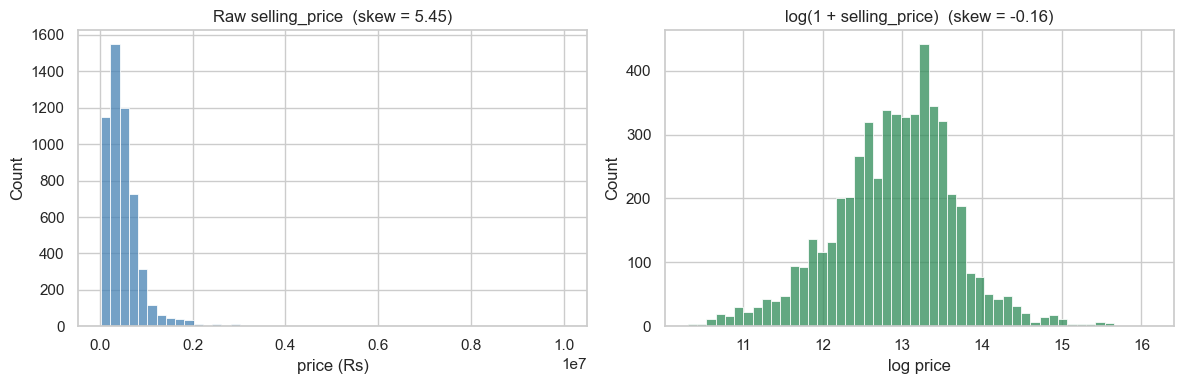

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(eda["selling_price"], bins=50, ax=ax[0], color="steelblue")
ax[0].set_title(f"Raw selling_price  (skew = {eda['selling_price'].skew():.2f})")
ax[0].set_xlabel("price (Rs)")

sns.histplot(np.log1p(eda["selling_price"]), bins=50, ax=ax[1], color="seagreen")
ax[1].set_title(f"log(1 + selling_price)  (skew = {np.log1p(eda['selling_price']).skew():.2f})")
ax[1].set_xlabel("log price")

plt.tight_layout()
plt.show()

**What we see:** the raw price is heavily **right-skewed** (skew ≈ 5.5) — most cars are cheap, a long tail of luxury cars stretches to ₹100 lakh. Taking the **log** turns it into a near-symmetric bell (skew ≈ 0).



## 2. What drives price? — correlations



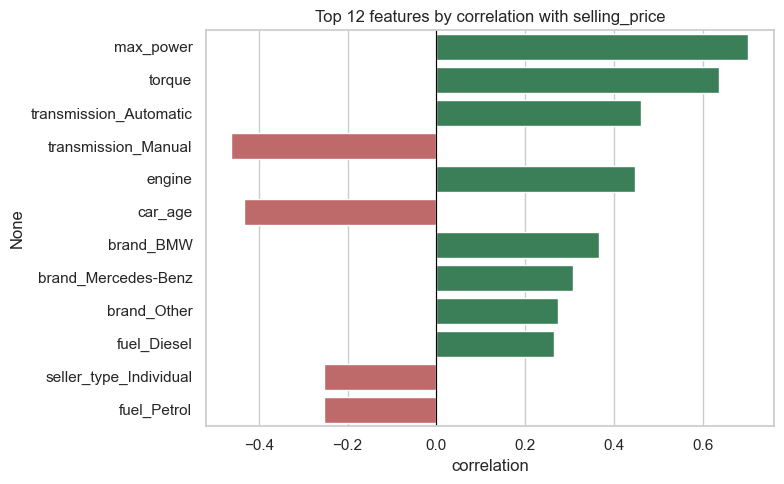

In [10]:
corr = eda.corr(numeric_only=True)["selling_price"].drop("selling_price")
top = corr.reindex(corr.abs().sort_values(ascending=False).index).head(12)

plt.figure(figsize=(8, 5))
colors = ["seagreen" if v > 0 else "indianred" for v in top.values]
sns.barplot(x=top.values, y=top.index, palette=colors, hue=top.index, legend=False)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top 12 features by correlation with selling_price")
plt.xlabel("correlation")
plt.tight_layout()
plt.show()

**What we see:**
- **`max_power` (≈0.70)** and **`torque` (≈0.64)** are the strongest drivers — more powerful cars cost more. Makes sense.
- **`transmission_Automatic` (≈+0.46)** vs **`transmission_Manual` (≈-0.46)** — automatics command a clear premium (they're mirror images because it's a 2-category one-hot).
- **`engine` (≈0.45)** — bigger engines, higher price.
- **`car_age` (≈-0.43)** — the only strong *negative*: older cars are worth less. Exactly the intuitive direction, which is why we engineered `car_age` instead of raw `year`.
- Luxury brand flags (**BMW, Mercedes-Benz**) push price up.



## 3. Key relationships up close



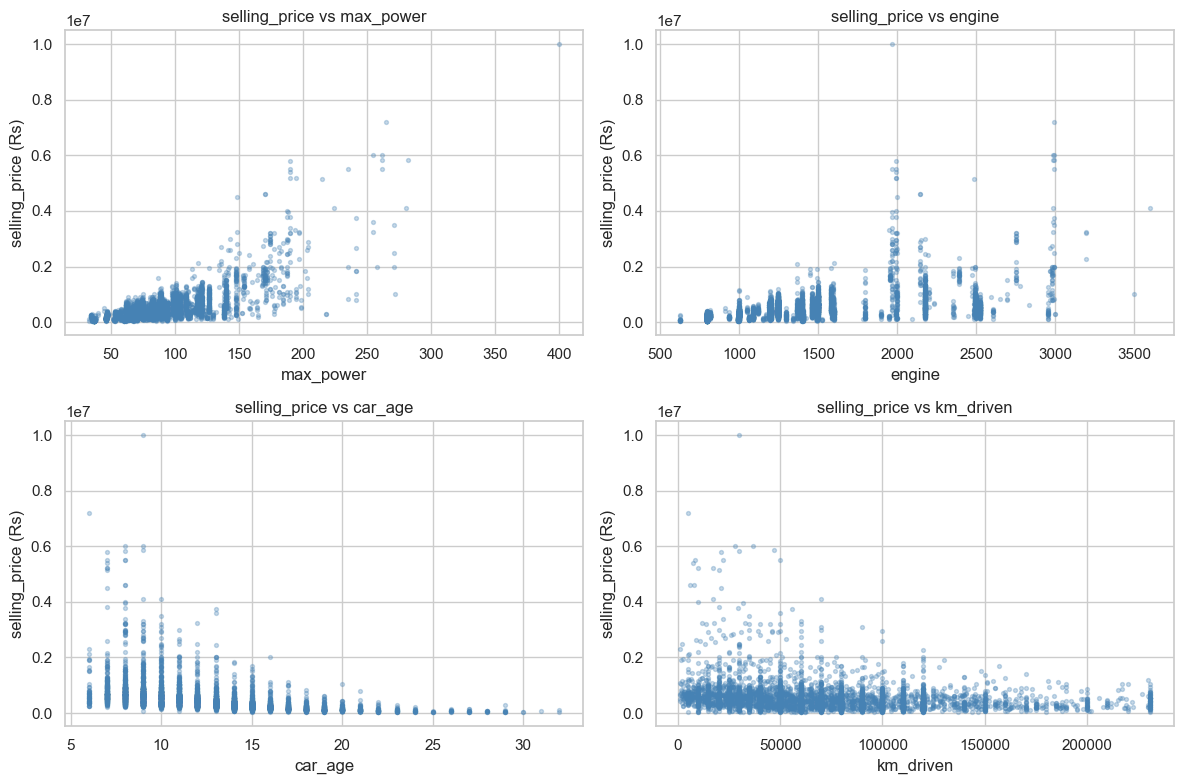

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), ["max_power", "engine", "car_age", "km_driven"]):
    ax.scatter(eda[col], eda["selling_price"], s=8, alpha=0.3, color="steelblue")
    ax.set_xlabel(col)
    ax.set_ylabel("selling_price (Rs)")
    ax.set_title(f"selling_price vs {col}")
plt.tight_layout()
plt.show()

**What we see:** `max_power` and `engine` rise with price (the cloud fans upward — the spread *grows* at high values, a sign a log transform will help). `car_age` slopes downward. `km_driven` is a weak, noisy negative — high-mileage cars trend cheaper, but it's far from the whole story.

## 4. The automatic premium



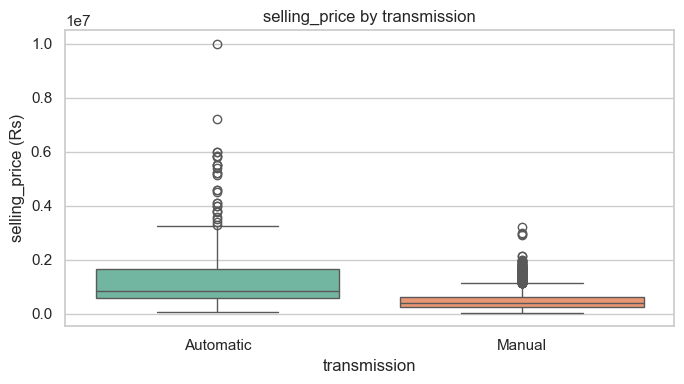

In [12]:
eda_t = eda.assign(transmission=np.where(eda["transmission_Automatic"] == 1, "Automatic", "Manual"))

plt.figure(figsize=(7, 4))
sns.boxplot(data=eda_t, x="transmission", y="selling_price", hue="transmission",
            palette="Set2", legend=False)
plt.title("selling_price by transmission")
plt.ylabel("selling_price (Rs)")
plt.tight_layout()
plt.show()

**What we see:** automatics sit at a much higher median price with a wider top tail — they skew toward newer, premium cars. A simple binary feature with a big price signal.

---

# Baseline model — Linear Regression

**Why linear regression as the baseline?** It's the simplest sensible model: fast, fully interpretable, and it gives us a *yardstick*. Every fancier model we try later (Random Forest, XGBoost) has to beat this number to justify its complexity. A baseline you can't beat tells you the problem is either easy or your features are weak — both useful to know.

We follow the same discipline as the cleaning: **learn on train, evaluate on the sealed test set.**
- `model.fit(X_train, y_train)` → the model learns
- `model.predict(X_test)` → it guesses, having never seen these rows


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features (X) vs target (y), per split — same X/y idea as before
X_train_m = train_clean.drop(columns=["selling_price"])
y_train_m = train_clean["selling_price"]
X_test_m  = test_clean.drop(columns=["selling_price"])
y_test_m  = test_clean["selling_price"]

# Defensive: make sure test columns line up exactly with train's
X_test_m = X_test_m.reindex(columns=X_train_m.columns, fill_value=0)

model = LinearRegression()
model.fit(X_train_m, y_train_m)          # LEARN — training rows only
y_pred = model.predict(X_test_m)         # PREDICT — sealed test rows

In [14]:
test_mae  = mean_absolute_error(y_test_m, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_m, y_pred))
test_r2   = r2_score(y_test_m, y_pred)

train_mae  = mean_absolute_error(y_train_m, model.predict(X_train_m))
train_rmse = np.sqrt(mean_squared_error(y_train_m, model.predict(X_train_m)))
train_r2   = r2_score(y_train_m, model.predict(X_train_m))


print("\n(Test) Baseline Linear Regression (raw target)")
print(f"Test  MAE  = ₹{test_mae:,.0f}   (average rupees off per car)")
print(f"Test  RMSE = ₹{test_rmse:,.0f}   (like MAE but punishes big misses harder)")
print(f"Test  R²   = {test_r2:.3f}        (fraction of price variation explained)")


print("\n(Train) Baseline Linear Regression (raw target)")
print(f"Train MAE  = ₹{train_mae:,.0f}   (average rupees off per car)")
print(f"Train RMSE = ₹{train_rmse:,.0f}   (like MAE but punishes big misses harder)")
print(f"Train R²   = {train_r2:.3f}        (fraction of price variation explained)")


(Test) Baseline Linear Regression (raw target)
Test  MAE  = ₹144,836   (average rupees off per car)
Test  RMSE = ₹286,556   (like MAE but punishes big misses harder)
Test  R²   = 0.739        (fraction of price variation explained)

(Train) Baseline Linear Regression (raw target)
Train MAE  = ₹141,839   (average rupees off per car)
Train RMSE = ₹268,510   (like MAE but punishes big misses harder)
Train R²   = 0.735        (fraction of price variation explained)


**Reading the score:**
- **R² ≈ 0.74** — the model explains about 74% of the variation in price from the features. For a first linear pass, that's a solid, healthy baseline.
- **MAE ≈ ₹1.45 lakh** — on a typical car its guess is off by roughly ₹1.45 lakh.


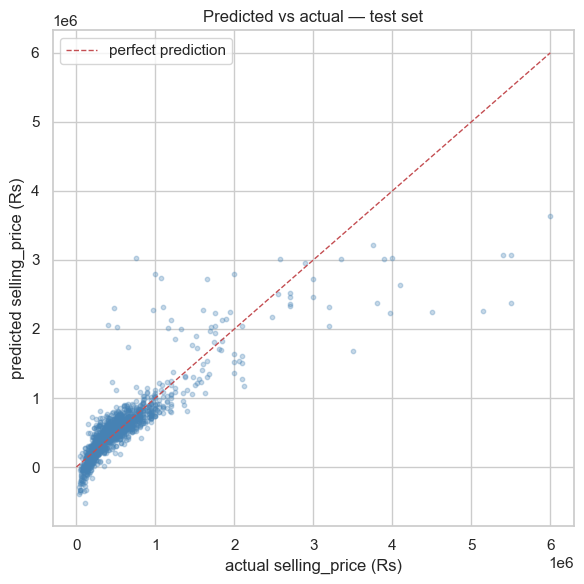

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_m, y_pred, s=10, alpha=0.3, color="steelblue")
lim = [0, y_test_m.max()]
plt.plot(lim, lim, "r--", linewidth=1, label="perfect prediction")
plt.xlabel("actual selling_price (Rs)")
plt.ylabel("predicted selling_price (Rs)")
plt.title("Predicted vs actual — test set")
plt.legend()
plt.tight_layout()
plt.show()

**What the plot shows:** points hug the red line for cheaper cars but scatter wildly — and the model even predicts **negative prices** — for expensive ones. A plain linear model on the raw, skewed target struggles at the top end.


---

# Experiment 1 — Log-transform the target

The EDA showed `selling_price` is heavily right-skewed, and the baseline confirmed the damage: wild misses on expensive cars, even negative predictions. The fix is to train on **`log(price)`** instead of raw price.

**The mechanic — three steps:**
1. Transform the target with `np.log1p` (= `log(1 + price)`) *before* fitting.
2. Fit the model on that log target.
3. Convert predictions back to rupees with `np.expm1` (the inverse) so we can score on the **same rupee scale** as the baseline — otherwise the comparison would be apples-to-oranges.

Everything else (features, train/test split, leakage discipline) stays identical, so any change in score is attributable to the log transform alone.

In [16]:
# Step 1: transform the target to log-space (training labels only — same leakage rule)
y_train_log = np.log1p(y_train_m)

# Step 2: fit on log(price)
log_model = LinearRegression()
log_model.fit(X_train_m, y_train_log)

# Step 3: predict, then convert back to rupees with expm1 (inverse of log1p)
y_pred_log = np.expm1(log_model.predict(X_test_m))

In [17]:
mae_log  = mean_absolute_error(y_test_m, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test_m, y_pred_log))
r2_log   = r2_score(y_test_m, y_pred_log)

print("Log-target Linear Regression (scored back on the rupee scale)")
print(f"  MAE  = ₹{mae_log:,.0f}")
print(f"  RMSE = ₹{rmse_log:,.0f}")
print(f"  R²   = {r2_log:.3f}")
print(f"  negative predictions: {(y_pred_log < 0).sum()}  (log guarantees zero)")

Log-target Linear Regression (scored back on the rupee scale)
  MAE  = ₹105,229
  RMSE = ₹215,978
  R²   = 0.852
  negative predictions: 0  (log guarantees zero)


## Baseline vs log target — side by side

`test_mae`, `test_rmse`, `test_r2` are still in memory from the baseline cell, so we can tabulate both directly.

In [18]:
comparison = pd.DataFrame(
    {"Baseline (raw target)": [test_r2, test_mae, test_rmse],
     "Log target":           [r2_log, mae_log, rmse_log]},
    index=["R²", "MAE (Rs)", "RMSE (Rs)"],
)
comparison["improvement"] = comparison["Log target"] - comparison["Baseline (raw target)"]
comparison.round(3)

,Baseline (raw target),Log target,improvement
R²,0.739,0.852,0.113
MAE (Rs),144835.887,105229.375,-39606.513
RMSE (Rs),286555.665,215978.488,-70577.177


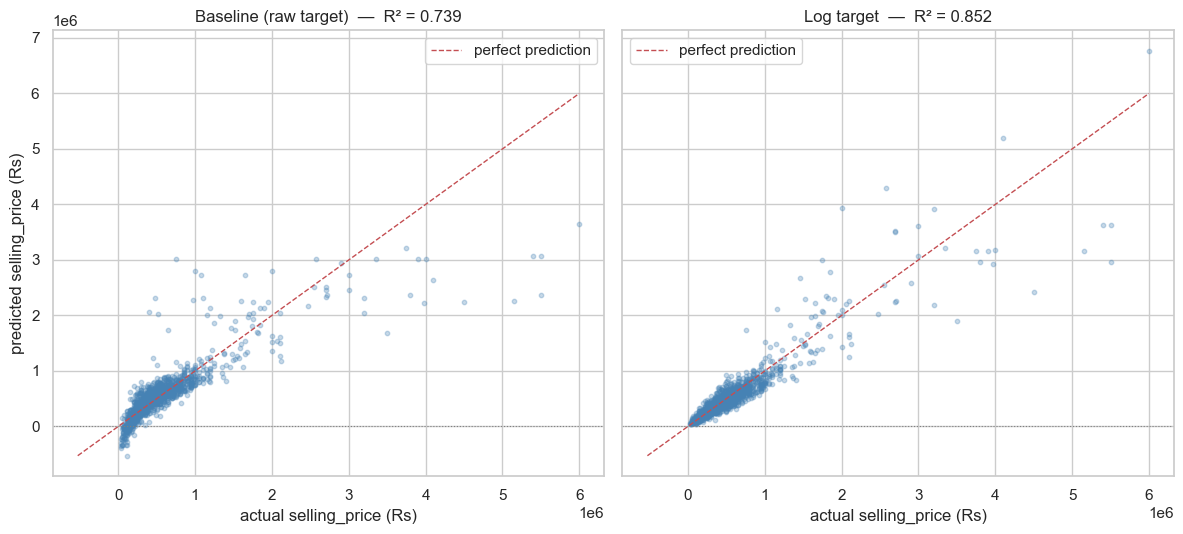

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True)
lim = [min(y_test_m.min(), y_pred.min()), y_test_m.max()]

for a, preds, title, r2v in [
    (ax[0], y_pred,     "Baseline (raw target)", test_r2),
    (ax[1], y_pred_log, "Log target",            r2_log),
]:
    a.scatter(y_test_m, preds, s=10, alpha=0.3, color="steelblue")
    a.plot(lim, lim, "r--", linewidth=1, label="perfect prediction")
    a.axhline(0, color="gray", linewidth=0.8, linestyle=":")
    a.set_xlabel("actual selling_price (Rs)")
    a.set_title(f"{title}  —  R² = {r2v:.3f}")
    a.legend()
ax[0].set_ylabel("predicted selling_price (Rs)")
plt.tight_layout()
plt.show()

**What changed:**
- **R² rose from ≈0.74 to ≈0.85** — the log model explains markedly more of the price variation.
- **MAE dropped by ≈₹40k** — its typical guess is closer.
- **Zero negative predictions** — the `expm1` step makes them mathematically impossible, so the left plot's dip below the gray zero-line is gone on the right.
- The right-hand cloud **hugs the diagonal more tightly**, especially at the high end where the baseline fell apart.

This matches exactly what the theory predicted: proportional errors, multiplicative effects made additive, a positive floor, and an evened-out error spread.

---

## Where we are / what's next

**Best model so far:** Linear Regression on the **log target** — R² ≈ 0.85, MAE ≈ ₹1.05 lakh. This is now the number to beat.

Next experiment: **tree-based models** (Random Forest, then gradient boosting / XGBoost). Trees capture the *curved* and *interaction* effects a straight line can't — and notably, they're insensitive to target skew, so we'll compare them on the raw target and see whether they beat the log-linear model. We'll stop here for today.